In [407]:
!pip install -q graphviz scikit-learn shap

In [434]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib import pyplot as plt
import seaborn as sns

In [435]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [436]:
df.columns

Index(['quantity_in', 'bill_date', 'shipped_date', 'due_date', 'eta', 'seal',
       'customs_broker', 'yield_percentage', 'shipment_classified'],
      dtype='object')

In [411]:
# columns_to_drop = ['receipt_date', 'shipment_delay_days', 'shipment_terms','vessel__voyage',]
# df = df.drop(columns=columns_to_drop)

In [412]:
# df['payment_terms'] = df['payment_terms'].astype(str).str.lower().str.strip()

In [413]:
# --- 1️⃣ Copy dataframe ---
df_encoded = df.copy()


# --- 3️⃣ Encode target column ---
df_encoded["shipment_classified"] = df_encoded["shipment_classified"].map(
    {"on_time": 0, "delayed": 1}
)

# --- 4️⃣ Convert date columns ---
date_columns = [
    "eta",
    "due_date",
    "bill_date",
    "shipped_date",
]  # 'receipt_date' will only be placed after shipment is received
for col in date_columns:
    df_encoded[col] = pd.to_datetime(df_encoded[col], errors="coerce")


# for col in date_columns: 
#     df_encoded[f'{col}_month'] = df_encoded[f'{col}'].dt.month 
#     df_encoded[f'{col}_month'] = df_encoded[f'{col}_month'].astype('str') 
#     df_encoded[f'{col}_weekday'] = df_encoded[f'{col}'].dt.weekday 
#     df_encoded[f'{col}_weekday'] = df_encoded[f'{col}_weekday'].astype('str')



# df_encoded["eta_weekday"] = df_encoded["eta"].dt.weekday

df_encoded["gap_between_due_and_eta"] = (df_encoded["due_date"] - df_encoded["eta"]).dt.days
df_encoded["gap_between_shipped_and_due"] = (df_encoded["due_date"] - df_encoded["shipped_date"]).dt.days


df_encoded["gap_between_bill_and_shipment"] = (
    df_encoded["bill_date"] - df_encoded["shipped_date"]
).dt.days
df_encoded["gap_between_eta_shipped"] = (
    df_encoded["eta"] - df_encoded["shipped_date"]
).dt.days
df_encoded["gap_between_eta_bill"] = (
    df_encoded["eta"] - df_encoded["bill_date"]
).dt.days

df_encoded["due_gap"] = (
    pd.to_datetime(df_encoded["due_date"]) - pd.to_datetime(df_encoded["bill_date"])
).dt.days
df_encoded["responsiveness"] = (
    df_encoded["bill_date"] - df_encoded["shipped_date"]
).dt.days

df_encoded["broker_frequency"] = df_encoded["customs_broker"].map(
    df_encoded["customs_broker"].value_counts()
)

df_encoded.drop(["customs_broker"] + date_columns, axis=1, inplace=True)


# --- 8️⃣ Handle categorical columns ---
categorical_cols = ["seal"]
from sklearn.preprocessing import LabelEncoder

for col in categorical_cols:
    if df_encoded[col].nunique() > 100:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))


# X, y split for training
X = df_encoded.drop("shipment_classified", axis=1)
y = df_encoded["shipment_classified"]

In [414]:
# Step 2: Data preprocessing
# df['inventory'] = df['inventory'].map({'Yes': 1, 'No': 0})
# df['shipment_classified'] = df['shipment_classified'].map({'on_time': 0, 'delayed': 1})

In [415]:
# Encode categorical columns
# cat_cols = df.select_dtypes(include=['object']).columns
# le = LabelEncoder()
# for col in cat_cols:
#     df[col] = le.fit_transform(df[col])

In [416]:
df_encoded

,quantity_in,seal,yield_percentage,shipment_classified,gap_between_due_and_eta,gap_between_shipped_and_due,gap_between_bill_and_shipment,gap_between_eta_shipped,gap_between_eta_bill,due_gap,responsiveness,broker_frequency
0,29892.0,1103,0.0,0,34,83,53,49,-4,30,53,16
1,4452.0,1103,0.0,0,34,83,53,49,-4,30,53,16
2,34020.0,990,79.0,0,4,70,70,66,-4,0,70,421
3,35280.0,239,105.0,0,5,60,60,55,-5,0,60,41
4,35280.0,872,78.0,0,3,51,51,48,-3,0,51,421
...,...,...,...,...,...,...,...,...,...,...,...,...
1785,30600.0,662,78.0,0,32,60,0,28,28,60,0,47
1786,30600.0,272,78.0,1,20,60,0,40,40,60,0,136
1787,36000.0,19,99.0,0,-40,0,0,40,40,0,0,708
1788,33750.0,256,86.0,1,15,60,0,45,45,60,0,136


In [417]:
# # Step 3: Split features & target
# X = df.drop('shipment_classified', axis=1)
# y = df['shipment_classified']

In [418]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [419]:
# Step 5: Scale features
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [420]:
# Step 6: Train model
model = RandomForestClassifier(class_weight="balanced", random_state=42, n_estimators=20)
model.fit(X_train, y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [433]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)
from sklearn.metrics import make_scorer, f1_score

from sklearn.model_selection import cross_validate

results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

print("Mean Accuracy:", round(results['test_accuracy'].mean(),2))
print("Mean Precision:", results['test_precision'].mean())
print("Mean Recall:", results['test_recall'].mean())
print("Mean F1:", results['test_f1'].mean())



Mean Accuracy: 0.97
Mean Precision: 0.9646341036414565
Mean Recall: 0.8507352941176471
Mean F1: 0.9008667658488211


In [422]:
# Step 7: Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9692737430167597

Confusion Matrix:
 [[292   2]
 [  9  55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       294
           1       0.96      0.86      0.91        64

    accuracy                           0.97       358
   macro avg       0.97      0.93      0.95       358
weighted avg       0.97      0.97      0.97       358



In [423]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop features influencing delay:\n", importance.head(10))


Top features influencing delay:
 gap_between_eta_bill             0.489858
gap_between_due_and_eta          0.140487
responsiveness                   0.066206
seal                             0.063709
gap_between_eta_shipped          0.052933
gap_between_bill_and_shipment    0.049964
gap_between_shipped_and_due      0.033050
quantity_in                      0.031708
due_gap                          0.026646
broker_frequency                 0.024928
dtype: float64


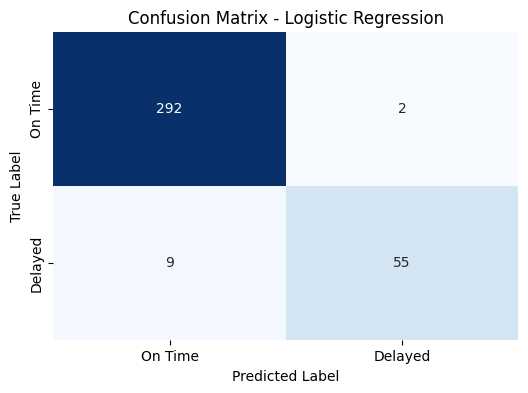

In [424]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [425]:
# from sklearn.tree import export_graphviz
# import graphviz

# # Assuming model is your trained RandomForestClassifier
# # Select the first tree from the Random Forest
# tree = model.estimators_[0]

# # Export the tree to a DOT format
# dot_data = export_graphviz(
#     tree,
#     out_file=None,  # Set to None to get DOT data as string
#     feature_names=X_train.columns,  # Replace with your feature names
#     class_names=model.classes_.astype(str),  # Replace with your class names
#     filled=True,  # Color nodes based on class
#     rounded=True,  # Rounded boxes for better visuals
#     special_characters=True
# )

# # Visualize the tree using graphviz
# graph = graphviz.Source(dot_data)
# graph.render("random_forest_tree", format="png", view=True)  # Saves and opens as PNG

## Explainable AI

In [426]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

# Assuming model is a trained RandomForestClassifier and X_test is your test data
sample_idx = 0
sample = X_test.iloc[[sample_idx]]  # select one sample

# Iterate through each tree in the Random Forest
for tree_idx, tree in enumerate(model.estimators_):
    node_indicator = tree.decision_path(sample)
    leaf_id = tree.apply(sample)

    node_index = node_indicator.indices  # nodes traversed by the sample

    print(f"\nTree {tree_idx + 1} Decision Path for Sample {sample_idx}:")
    for node_id in node_index:
        feature_idx = tree.tree_.feature[node_id]
        threshold = tree.tree_.threshold[node_id]

        if feature_idx != -2:  # non-leaf node
            feature_name = X_test.columns[feature_idx] if hasattr(X_test, "columns") else f"Feature {feature_idx}"
            print(f"Node {node_id}: {feature_name} <= {threshold:.4f}")
        else:
            # Leaf node
            value = tree.tree_.value[node_id]
            class_name = model.classes_[np.argmax(value)]
            print(f"Node {node_id}: Leaf (Predicted Class: {class_name})")

# Final prediction
prediction = model.predict(sample)[0]
print(f"\nFinal Prediction for Sample {sample_idx}: {prediction}")



Tree 1 Decision Path for Sample 0:
Node 0: responsiveness <= 60.5000
Node 1: gap_between_eta_bill <= -5.5000
Node 3: gap_between_eta_shipped <= 44.5000
Node 4: gap_between_bill_and_shipment <= 36.5000
Node 5: gap_between_eta_bill <= 37.5000
Node 6: gap_between_due_and_eta <= -31.5000
Node 7: gap_between_eta_shipped <= 36.5000
Node 27: quantity_in <= 33885.0000
Node 31: broker_frequency <= 276.5000
Node 32: Leaf (Predicted Class: 0)

Tree 2 Decision Path for Sample 0:
Node 0: gap_between_eta_bill <= -5.5000
Node 2: due_gap <= 13.0000
Node 3: gap_between_shipped_and_due <= 0.5000
Node 4: yield_percentage <= 87.5000
Node 5: gap_between_eta_shipped <= 31.5000
Node 9: broker_frequency <= 564.5000
Node 10: Leaf (Predicted Class: 0)

Tree 3 Decision Path for Sample 0:
Node 0: gap_between_due_and_eta <= 5.5000
Node 1: gap_between_shipped_and_due <= 14.5000
Node 2: seal <= 710.0000
Node 10: seal <= 1061.5000
Node 11: quantity_in <= 32320.0000
Node 21: broker_frequency <= 276.5000
Node 22: resp

/Users/prashant/.pyenv/versions/3.13.7/envs/ideabox-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/prashant/.pyenv/versions/3.13.7/envs/ideabox-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/prashant/.pyenv/versions/3.13.7/envs/ideabox-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/prashant/.pyenv/versions/3.13.7/envs/ideabox-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/prashant/.pyenv/versions/3.13.7/envs/ideabox-env/lib/python3.13/site-pack

In [427]:
X.columns

Index(['quantity_in', 'seal', 'yield_percentage', 'gap_between_due_and_eta',
       'gap_between_shipped_and_due', 'gap_between_bill_and_shipment',
       'gap_between_eta_shipped', 'gap_between_eta_bill', 'due_gap',
       'responsiveness', 'broker_frequency'],
      dtype='object')

/Users/prashant/.pyenv/versions/3.13.7/envs/ideabox-env/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/Users/prashant/.pyenv/versions/3.13.7/envs/ideabox-env/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/Users/p

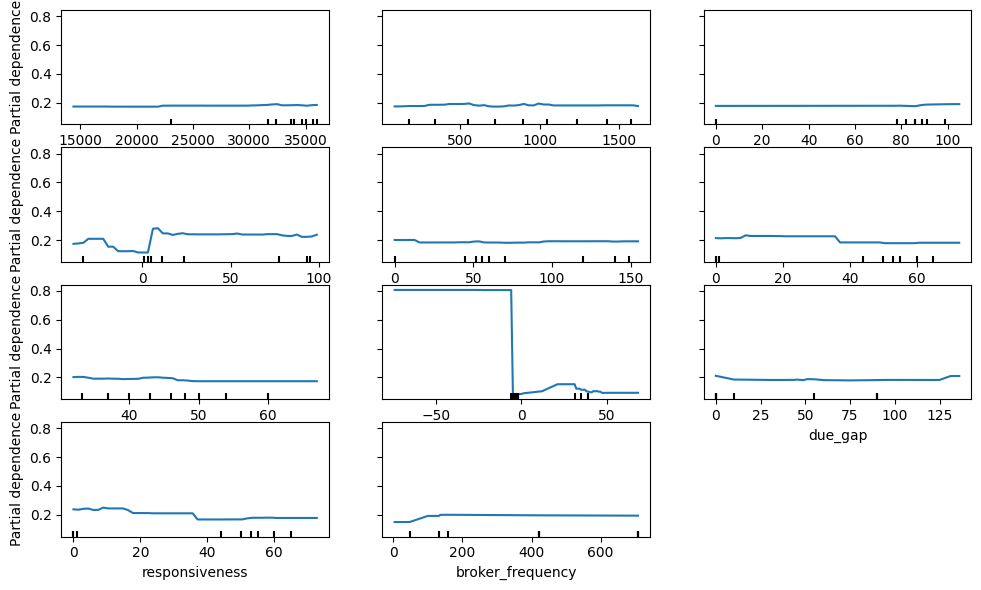

In [428]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Assuming model is your trained RandomForestClassifier and X_test is your test data
# Specify features to plot (use indices or feature names)
features = ['quantity_in', 'seal', 'yield_percentage', 'gap_between_due_and_eta',
       'gap_between_shipped_and_due', 'gap_between_bill_and_shipment',
       'gap_between_eta_shipped', 'gap_between_eta_bill', 'due_gap',
       'responsiveness', 'broker_frequency']

# Create and plot partial dependence
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=features,  # Features to analyze
    kind='average',     # Show average effect (use 'individual' for ICE plots)
    grid_resolution=50, # Number of points to evaluate
    ax=ax
)
plt.tight_layout()
plt.show()

In [429]:
from sklearn.inspection import permutation_importance

r = permutation_importance(model, X, y, n_repeats=10, random_state=42)
perm_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': r.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_importance)


                          Feature  Importance
7            gap_between_eta_bill    0.229385
3         gap_between_due_and_eta    0.027654
1                            seal    0.025531
6         gap_between_eta_shipped    0.020335
9                  responsiveness    0.019609
5   gap_between_bill_and_shipment    0.017318
0                     quantity_in    0.011285
2                yield_percentage    0.007039
10               broker_frequency    0.006425
4     gap_between_shipped_and_due    0.005140
8                         due_gap    0.003408


/Users/prashant/.pyenv/versions/3.13.7/envs/ideabox-env/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 6 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/Users/prashant/.pyenv/versions/3.13.7/envs/ideabox-env/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 8 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


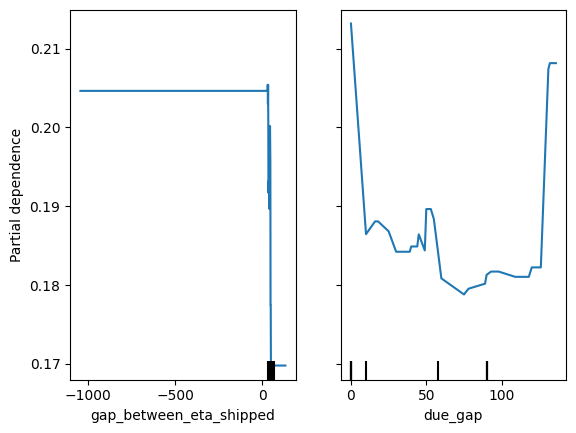

In [430]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(model, X, ['gap_between_eta_shipped', 'due_gap'])


In [431]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values[1], X)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X)  # modern SHAP call

# This returns a SHAP object that handles multi-class automatically
shap.summary_plot(shap_values.values, X)


In [ ]:
!pip install -q lime ipython==8.22 --upgrade

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML

explainer = LimeTabularExplainer(
    X.values, feature_names=X.columns, class_names=['on_time','delayed'], discretize_continuous=True
)

exp = explainer.explain_instance(X.iloc[0].values, model.predict_proba)
exp.show_in_notebook(show_table=True)
